# Language Model

This notebook covers the full language model pipeline on top of a pre-trained DBConformer acoustic model:

1. **Setup** — installs, imports, Drive mount
2. **Configuration** — paths & hyperparameters
3. **Acoustic model** — load DBConformer checkpoint, run inference, build mixed LM training data
6. **BART evaluation** — WER / PER / BLEU / ROUGE with plots
7. **Qwen evaluation** — same metrics
8. **LM Uncertainty** — BART & Qwen beam-score uncertainty

**Prerequisites:** DBConformer checkpoint already trained and saved to Drive.

# Dependency

In [1]:
!pip install -q evaluate jiwer rouge_score
!pip install -q trl
!pip install -q -U bitsandbytes>=0.46.1
!pip install -q einops timm h5py seaborn

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 127.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 528.8/528.8 kB 37.0 MB/s eta 0:00:00


In [2]:
import gc
import os
import pickle
import random
import re
import shutil
import warnings
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import Tensor
from torch.backends import cudnn
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import DataLoader, Sampler, Dataset as TorchDataset
from tqdm.auto import tqdm
from einops import rearrange
from timm.models.layers import trunc_normal_

import datasets
import evaluate
import jiwer
from datasets import Dataset
from google.colab import drive

from transformers import (
    AutoModelForCausalLM,
    AutoModelForSeq2SeqLM,
    AutoTokenizer,
    BitsAndBytesConfig,
    DataCollatorForSeq2Seq,
    EarlyStoppingCallback,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments,
)
from peft import LoraConfig, PeftModel, get_peft_model, prepare_model_for_kbit_training
from trl import SFTConfig, SFTTrainer
from peft import PeftModel
from huggingface_hub import login
warnings.filterwarnings('ignore')
cudnn.benchmark = False
cudnn.deterministic = True

LOGIT_TO_PHONEME = [
    'BLANK',
    'AA', 'AE', 'AH', 'AO', 'AW', 'AY', 'B',  'CH', 'D',  'DH',
    'EH', 'ER', 'EY', 'F',  'G',  'HH', 'IH', 'IY', 'JH', 'K',
    'L',  'M',  'N',  'NG', 'OW', 'OY', 'P',  'R',  'S',  'SH',
    'T',  'TH', 'UH', 'UW', 'V',  'W',  'Y',  'Z',  'ZH', '|',
]
NUM_PHONEMES = len(LOGIT_TO_PHONEME)  # 41

print('Imports OK | PyTorch:', torch.__version__)
print('CUDA:', torch.cuda.is_available())

/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


Imports OK | PyTorch: 2.10.0+cu128
CUDA: True


In [3]:
drive.mount('/content/drive')

Mounted at /content/drive


# Utility

## load weight&data



*   Model Weights

The pretrained weights for these network are available at:

BART：
https://drive.google.com/drive/folders/1lUDsz2-Bvsg623hJzEg7X9eizkTYKgLi?usp=drive_link

QWEN：https://drive.google.com/drive/folders/1iQFunPJHNK-2_kzuwg4_z3-u7PaslCn9?usp=drive_link
*   DATA

The data for inference are available at: [Google Drive]
https://drive.google.com/file/d/1jumosK6v5lngly8MzqbpkDEjyaSdxMRE/view?usp=drive_link and replace the path in code.






In [4]:
# ================================================================
#  CONFIGURATION — edit these before running
# ================================================================
import argparse

# Acoustic model checkpoint (DBConformer)
ACOUSTIC_CKPT = '/content/drive/MyDrive/DBConformer_runs_512/NeuralPhoneme/DBConformerCTC_t15.2023.08.18_best.ckpt'

# Cached val/train index pkl files (faster than re-loading HDF5 every session)
VAL_PKL   = '/content/drive/MyDrive/val_index_merged.pkl'

# Save directories for LM checkpoints
BART_SAVE   =  "/content/drive/MyDrive/SpeechModels/BART_Phoneme_to_Text_Final"
QWEN_LORA_SAVE   = '/content/drive/MyDrive/SpeechModels/Qwen2.5_Phoneme_to_Text_LoRA_syntactic'

# DBConformer args (must match the trained checkpoint)
args = argparse.Namespace(
    data_name='NeuralPhoneme', session='t15.2023.08.18',
    chn=512, time_sample_num=1500,
    emb_size=512, spa_dim=16,
    transformer_depth_tem=6, transformer_depth_chn=6,
    temporal_kernel=15, pool_kernel=15, pool_stride=8,
    gate_flag=False, posemb_flag=True, chn_atten_flag=True, branch='all',
    ffn_hidden=1024, class_num=NUM_PHONEMES,
    dropoutRate=0.3, lr=1e-3, batch_size=28, max_epoch=100,
    eval_interval=5, max_time_steps=1500,
)

torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


In [5]:
# ================================================================
# Data helpers
# ================================================================

class SpeechDatasetWithText(TorchDataset):
    def __init__(self, data_dict, max_time_steps=1500):
        self.data = data_dict
        self.length = len(data_dict['neural_features'])
        self.max_time_steps = max_time_steps

    def __len__(self): return self.length

    def __getitem__(self, idx):
        n_time_steps = int(self.data['n_time_steps'][idx])
        seq_len = int(self.data['seq_len'][idx])
        effective_n_steps = min(n_time_steps, self.max_time_steps)
        neural   = self.data['neural_features'][idx][:effective_n_steps]
        phonemes = self.data['seq_class_ids'][idx][:seq_len]
        text_label = self.data['sentence_label'][idx]
        if isinstance(text_label, bytes): text_label = text_label.decode('utf-8')
        neural_tensor  = torch.from_numpy(neural).float().transpose(0, 1).unsqueeze(0)
        phoneme_tensor = torch.from_numpy(phonemes.astype(np.int64))
        return neural_tensor, phoneme_tensor, seq_len, effective_n_steps, text_label


class BucketBatchSampler(Sampler):
    def __init__(self, dataset, batch_size, drop_last=False):
        self.dataset = dataset; self.batch_size = batch_size; self.drop_last = drop_last
        self.sorted_indices = sorted(range(len(dataset)), key=lambda i: dataset.data['n_time_steps'][i])
    def __iter__(self):
        batches = [self.sorted_indices[i:i+self.batch_size] for i in range(0, len(self.sorted_indices), self.batch_size)]
        random.shuffle(batches)
        for b in batches:
            if not self.drop_last or len(b) == self.batch_size: yield b
    def __len__(self):
        return len(self.dataset)//self.batch_size if self.drop_last else (len(self.dataset)+self.batch_size-1)//self.batch_size


def collate_fn_with_text(batch):
    neurals, phonemes_list, seq_lens, time_steps, texts = zip(*batch)
    neurals_reshaped = [n.squeeze(0).transpose(0, 1) for n in neurals]
    neural_batch = pad_sequence(neurals_reshaped, batch_first=True).transpose(1, 2).unsqueeze(1)
    phoneme_batch = pad_sequence(phonemes_list, batch_first=True, padding_value=0)
    return (neural_batch, phoneme_batch,
            torch.tensor(seq_lens, dtype=torch.long),
            torch.tensor(time_steps, dtype=torch.long), texts)


def compute_token_lengths(input_time_steps, pool_kernel, pool_stride):
    return ((input_time_steps - pool_kernel) // pool_stride + 1).long()


def decode_phonemes_to_letters(seq_ids):
    return ' '.join(LOGIT_TO_PHONEME[p] for p in seq_ids if p != 0 and p < NUM_PHONEMES)


def decode_text_labels(labels):
    return [t.decode('utf-8') if isinstance(t, bytes) else str(t) for t in labels]


print('Data helpers defined.')

Data helpers defined.


In [6]:
# ================================================================
# DBConformer model definition (needed to load acoustic checkpoint)
# ================================================================

class Conv(nn.Module):
    def __init__(self, conv, activation=None, bn=None):
        super().__init__()
        self.conv=conv; self.activation=activation
        if bn: self.conv.bias=None
        self.bn=bn
    def forward(self,x):
        x=self.conv(x)
        if self.bn: x=self.bn(x)
        if self.activation: x=self.activation(x)
        return x

class InterFre(nn.Module):
    def forward(self,x): return F.gelu(sum(x))

class Stem(nn.Module):
    def __init__(self,data_name,in_planes,out_planes=64,kernel_size=15,pool_kernel=15,pool_stride=8,radix=2):
        super().__init__()
        self.out_planes=out_planes; self.mid_planes=out_planes*radix; self.radix=radix
        self.sconv=Conv(nn.Conv1d(in_planes,self.mid_planes,1,bias=False,groups=radix),bn=nn.BatchNorm1d(self.mid_planes))
        self.tconv=nn.ModuleList(); ks=kernel_size
        for _ in range(radix):
            self.tconv.append(Conv(nn.Conv1d(out_planes,out_planes,ks,1,groups=out_planes,padding=ks//2,bias=False),bn=nn.BatchNorm1d(out_planes)))
            ks=max(ks//2,3)
        self.interFre=InterFre(); self.downSampling=nn.AvgPool1d(pool_kernel,pool_stride); self.dp=nn.Dropout(0.5)
    def forward(self,x):
        out=self.sconv(x); out=torch.split(out,self.out_planes,dim=1)
        out=[m(xi) for xi,m in zip(out,self.tconv)]
        return self.dp(self.downSampling(self.interFre(out)))

class PatchEmbeddingTemporal(nn.Module):
    def __init__(self,data_name,in_planes,out_planes,kernel_size,radix,pool_kernel,pool_stride,time_points,num_classes):
        super().__init__()
        self.stem=Stem(data_name,in_planes*radix,out_planes,kernel_size,pool_kernel,pool_stride,radix)
        self.apply(self._init_weights)
    def _init_weights(self,m):
        if isinstance(m,nn.Linear): trunc_normal_(m.weight,std=.01); nn.init.constant_(m.bias,0) if m.bias is not None else None
        elif isinstance(m,(nn.LayerNorm,nn.BatchNorm1d,nn.BatchNorm2d)):
            if m.weight is not None: nn.init.constant_(m.weight,1.0)
            if m.bias is not None:   nn.init.constant_(m.bias,0)
        elif isinstance(m,(nn.Conv1d,nn.Conv2d)): trunc_normal_(m.weight,std=.01)
    def forward(self,x): return self.stem(x).permute(0,2,1)

class PatchEmbeddingSpatial(nn.Module):
    def __init__(self,spa_dim,emb_size=40):
        super().__init__()
        self.encoder=nn.Sequential(nn.Conv1d(1,spa_dim,25,5,12),nn.ELU(),nn.AdaptiveAvgPool1d(1),nn.Flatten(),nn.Linear(spa_dim,emb_size))
    def forward(self,x):
        B,C,T=x.shape; x=x.reshape(B*C,1,T); x=self.encoder(x); return x.view(B,C,-1)

class MultiHeadAttention(nn.Module):
    def __init__(self,emb_size,num_heads,dropout):
        super().__init__()
        self.num_heads=num_heads; self.dropout_p=dropout
        self.queries=nn.Linear(emb_size,emb_size); self.keys=nn.Linear(emb_size,emb_size)
        self.values=nn.Linear(emb_size,emb_size); self.projection=nn.Linear(emb_size,emb_size)
    def forward(self,x,mask=None):
        Q=rearrange(self.queries(x),'b n (h d)->b h n d',h=self.num_heads)
        K=rearrange(self.keys(x),   'b n (h d)->b h n d',h=self.num_heads)
        V=rearrange(self.values(x), 'b n (h d)->b h n d',h=self.num_heads)
        out=F.scaled_dot_product_attention(Q,K,V,attn_mask=mask,dropout_p=self.dropout_p if self.training else 0.,is_causal=False)
        return self.projection(rearrange(out,'b h n d->b n (h d)'))

class FeedForwardBlock(nn.Sequential):
    def __init__(self,emb_size,expansion=4,drop_p=0.3):
        super().__init__(nn.Linear(emb_size,expansion*emb_size),nn.GELU(),nn.Dropout(drop_p),nn.Linear(expansion*emb_size,emb_size))

class TransformerEncoderBlock(nn.Module):
    def __init__(self,emb_size,num_heads=8,drop_p=0.3,forward_expansion=4,forward_drop_p=0.3):
        super().__init__()
        self.norm1=nn.LayerNorm(emb_size); self.attn=MultiHeadAttention(emb_size,num_heads,drop_p); self.drop1=nn.Dropout(drop_p)
        self.norm2=nn.LayerNorm(emb_size); self.ff=FeedForwardBlock(emb_size,forward_expansion,forward_drop_p); self.drop2=nn.Dropout(drop_p)
    def forward(self,x,mask=None):
        res=x; x=self.norm1(x); x=self.attn(x,mask=mask); x=res+self.drop1(x)
        res=x; x=self.norm2(x); x=self.ff(x); x=res+self.drop2(x); return x

class TransformerEncoder(nn.Module):
    def __init__(self,depth,emb_size):
        super().__init__()
        self.layers=nn.ModuleList([TransformerEncoderBlock(emb_size) for _ in range(depth)])
    def forward(self,x,mask=None):
        for layer in self.layers: x=layer(x,mask=mask)
        return x

class CTCHead(nn.Module):
    def __init__(self,emb_size,num_classes,ffn_hidden=256,dropout=0.3):
        super().__init__()
        self.ffn=nn.Sequential(nn.LayerNorm(emb_size),nn.Linear(emb_size,ffn_hidden),nn.GELU(),nn.Dropout(dropout),nn.Linear(ffn_hidden,num_classes))
    def forward(self,x): return self.ffn(x).permute(1,0,2)

class DBConformer(nn.Module):
    def __init__(self,args,emb_size=128,tem_depth=6,chn_depth=6,chn=512,n_classes=41):
        super().__init__()
        self.embedding=PatchEmbeddingTemporal(args.data_name,args.chn,emb_size,args.temporal_kernel,1,args.pool_kernel,args.pool_stride,args.time_sample_num,args.class_num)
        self.channel_embedding=PatchEmbeddingSpatial(args.spa_dim,emb_size)
        self.C=args.chn; self.posemb_flag=args.posemb_flag
        if args.posemb_flag:
            P_init=max(1,args.time_sample_num//args.pool_stride)
            self.pos_embedding_temporal=nn.Parameter(torch.randn(1,P_init,emb_size))
            self.pos_embedding_spatial=nn.Parameter(torch.randn(1,self.C,emb_size))
        self.temporal_transformer=TransformerEncoder(tem_depth,emb_size)
        self.spatial_transformer=TransformerEncoder(chn_depth,emb_size)
    def forward(self,x,mask=None):
        x=x.squeeze(1); x_embed=self.embedding(x); x_spa=self.channel_embedding(x)
        if self.posemb_flag:
            pt=F.interpolate(self.pos_embedding_temporal.permute(0,2,1),size=x_embed.shape[1],mode='linear',align_corners=False).permute(0,2,1)
            x_embed=x_embed+pt
            ps=F.interpolate(self.pos_embedding_spatial.permute(0,2,1),size=x_spa.shape[1],mode='linear',align_corners=False).permute(0,2,1)
            x_spa=x_spa+ps
        x_temporal=self.temporal_transformer(x_embed,mask=mask); self.spatial_transformer(x_spa)
        return x_temporal,None

class DBConformerCTC(nn.Module):
    def __init__(self,backbone,emb_size,num_classes,ffn_hidden=256,dropout=0.3):
        super().__init__()
        self.backbone=backbone; self.ctc_head=CTCHead(emb_size,num_classes,ffn_hidden,dropout)
    def forward(self,x,mask=None): features,_=self.backbone(x,mask=mask); return self.ctc_head(features)

def backbone_net_dbconformer(args):
    return DBConformer(args,emb_size=args.emb_size,tem_depth=args.transformer_depth_tem,chn_depth=args.transformer_depth_chn,chn=args.chn,n_classes=args.class_num)

print('DBConformer defined.')

DBConformer defined.


In [7]:
# ================================================================
# Load acoustic model + data index
# ================================================================
gc.collect(); torch.cuda.empty_cache()

# Load data from pkl cache
print('Loading data index from pkl...')
with open(VAL_PKL,  'rb') as f: val_index   = pickle.load(f)
print(f'Val: {len(val_index["neural_features"])} trials')


# Load acoustic model
backbone = backbone_net_dbconformer(args)
acoustic_model = DBConformerCTC(
    backbone, emb_size=args.emb_size, num_classes=NUM_PHONEMES,
    ffn_hidden=args.ffn_hidden, dropout=args.dropoutRate).to(device)
state_dict = torch.load(ACOUSTIC_CKPT, map_location=device)
acoustic_model.load_state_dict(state_dict if 'model_state_dict' not in state_dict else state_dict['model_state_dict'])
acoustic_model.eval()
print(f'Acoustic model loaded from {ACOUSTIC_CKPT}')

def ctc_greedy_decode(log_probs, blank_id=0):
    pred_ids = torch.argmax(log_probs, dim=-1).transpose(0, 1)
    decoded_preds = []
    for seq in pred_ids:
        decoded=[]; prev=-1
        for tok in seq.tolist():
            if tok != prev and tok != blank_id: decoded.append(tok)
            prev=tok
        decoded_preds.append(decoded)
    return decoded_preds

def calculate_per(reference, hypothesis):
    m,n=len(reference),len(hypothesis)
    dp=list(range(n+1))
    for i in range(1,m+1):
        prev=dp[:]; dp[0]=i
        for j in range(1,n+1):
            dp[j]=min(prev[j]+1,dp[j-1]+1,prev[j-1]+(0 if reference[i-1]==hypothesis[j-1] else 1))
    return dp[n]/m if m>0 else 0.0

def calculate_wer(reference, hypothesis):
    ref=re.sub(r'[^\w\s]','',reference.lower()).split()
    hyp=re.sub(r'[^\w\s]','',hypothesis.lower()).split()
    m,n=len(ref),len(hyp)
    if m==0: return 1.0 if n>0 else 0.0
    dp=list(range(n+1))
    for i in range(1,m+1):
        prev=dp[:]; dp[0]=i
        for j in range(1,n+1):
            dp[j]=min(prev[j]+1,dp[j-1]+1,prev[j-1]+(0 if ref[i-1]==hyp[j-1] else 1))
    return dp[n]/m

def compute_am_sequence_score(log_probs, input_lengths):
    max_lp=log_probs.max(dim=-1)[0]
    return torch.tensor([-max_lp[:int(input_lengths[i].item()),i].mean().item() for i in range(log_probs.shape[1])])

print('All helpers defined.')

Loading data index from pkl...
Val: 1378 trials
Acoustic model loaded from /content/drive/MyDrive/DBConformer_runs_512/NeuralPhoneme/DBConformerCTC_t15.2023.08.18_best.ckpt
All helpers defined.


In [8]:
# Build DataLoaders
val_dataset_lm   = SpeechDatasetWithText(val_index,   max_time_steps=args.max_time_steps)
val_sampler_lm   = BucketBatchSampler(val_dataset_lm,   batch_size=args.batch_size)
val_loader   = DataLoader(val_dataset_lm,   batch_sampler=val_sampler_lm,
                          collate_fn=collate_fn_with_text, num_workers=2, pin_memory=True, prefetch_factor=2)


In [9]:
# ================================================================
# Phoneme confusion map & synthetic error injection
# ================================================================

VOCAB_PHONEMES = list(range(1, 40))

phoneme_confusion_map = {
    27:[7,31,20], 7:[27,9,15], 31:[9,27,20], 9:[31,7,15], 20:[15,31,27], 15:[20,9,7],
    14:[35,32,29], 35:[14,10,38], 32:[10,14,29], 10:[32,35,38], 29:[38,30,32],
    38:[29,39,10], 30:[39,29,8], 39:[30,38,19], 16:[32,14],
    8:[19,30,31], 19:[8,39,9],
    22:[23,24], 23:[22,24], 24:[23,22],
    21:[28,36,37], 28:[21,36], 36:[21,28,34], 37:[21,18],
    18:[17,13], 17:[18,11], 11:[17,2], 2:[11,1],
    1:[4,3], 4:[1,33], 33:[34,4], 34:[33,25], 3:[11,33,12], 12:[3,28],
    13:[11,18,6], 6:[1,18,13], 26:[4,18], 5:[1,34,25], 25:[4,34,5]
}

_ERR_TYPES = ['targeted_sub','random_sub','deletion','insertion']
_ERR_PROBS = [0.2126, 0.4508, 0.2134, 0.1232]

def inject_synthetic_errors(sequence, target_per=0.10):
    synthetic_seq = []
    for ph in sequence:
        if random.random() < target_per:
            err_type = np.random.choice(_ERR_TYPES, p=_ERR_PROBS)
            if err_type == 'targeted_sub':
                synthetic_seq.append(random.choice(phoneme_confusion_map[ph]) if ph in phoneme_confusion_map else random.choice([p for p in VOCAB_PHONEMES if p!=ph]))
            elif err_type == 'random_sub':
                synthetic_seq.append(random.choice([p for p in VOCAB_PHONEMES if p!=ph]))
            elif err_type == 'deletion':
                continue
            elif err_type == 'insertion':
                synthetic_seq.append(random.choice(VOCAB_PHONEMES)); synthetic_seq.append(ph)
        else:
            synthetic_seq.append(ph)
    return synthetic_seq


def build_lm_training_data(train_loader, acoustic_model, device):
    """Build mixed dataset: 20% GT + 60% synthetic + 20% predicted."""
    acoustic_model.eval()
    merged_phonemes, merged_texts = [], []
    print('Building mixed LM training dataset...')
    with torch.no_grad():
        for batch_feat, batch_ids, batch_lens, _, texts in tqdm(train_loader):
            batch_feat = batch_feat.to(device)
            log_probs = acoustic_model(batch_feat)
            predicted_seqs = ctc_greedy_decode(log_probs, blank_id=0)
            for b in range(len(batch_ids)):
                ref_seq = [x for x in batch_ids[b][:int(batch_lens[b].item())].tolist() if x != 0]
                text_label = texts[b]
                merged_phonemes.append(ref_seq);         merged_texts.append(text_label)  # GT
                for _ in range(3):                                                          # Synthetic x3
                    merged_phonemes.append(inject_synthetic_errors(ref_seq)); merged_texts.append(text_label)
                merged_phonemes.append(predicted_seqs[b]); merged_texts.append(text_label) # Predicted
    print(f'Mixed dataset: {len(merged_phonemes)} samples')
    return merged_phonemes, merged_texts


def build_val_hf_dataset(val_loader, acoustic_model, device, args):
    """Run acoustic inference on val set and return HuggingFace Dataset."""
    acoustic_model.eval()
    k_w, s_w = args.pool_kernel, args.pool_stride
    val_preds, val_labels, val_real = [], [], []
    print('Running acoustic inference on val set...')
    with torch.no_grad():
        for batch in tqdm(val_loader):
            feat, batch_ids, batch_lens, input_time_steps, text_labels = batch
            feat = feat.to(device)
            il = compute_token_lengths(input_time_steps, k_w, s_w).to(device)
            T_p = feat.size(-1)
            P = compute_token_lengths(torch.tensor([T_p]), k_w, s_w).item()
            seq_range = torch.arange(P, device=device).expand(feat.size(0), P)
            attn_mask = (seq_range < il.unsqueeze(1)).unsqueeze(1).unsqueeze(2)
            log_probs = acoustic_model(feat, mask=attn_mask)
            predictions = ctc_greedy_decode(log_probs, blank_id=0)
            for b, pred in enumerate(predictions):
                val_preds.append(decode_phonemes_to_letters(pred))
                ref_seq = [x for x in batch_ids[b][:int(batch_lens[b].item())].tolist() if x != 0]
                val_real.append(decode_phonemes_to_letters(ref_seq))
            val_labels.extend(decode_text_labels(text_labels))
    return Dataset.from_dict({'input_text': val_preds, 'target_text': val_labels, 'real_phonemes': val_real})


# --- Run both ---
val_dataset_hf = build_val_hf_dataset(val_loader, acoustic_model, device, args)
print(f'Val   HF dataset: {len(val_dataset_hf)} samples')

Running acoustic inference on val set...


  0%|          | 0/50 [00:00<?, ?it/s]

Val   HF dataset: 1378 samples


# Evaluation

Runs WER / PER / BLEU / ROUGE on the validation set for BART or Qwen.
Set `EVAL_MODEL_PATH` and `EVAL_TYPE` before running.

In [14]:
# ================================================================
# ⚙️  Evaluation config — edit before running
# ================================================================

EVAL_TYPE       = 'bart'   # 'bart' or 'qwen'
EVAL_MODEL_PATH = BART_SAVE   # path to the checkpoint to evaluate
EVAL_BEAM_SIZE  = 4
EVAL_BATCH_SIZE = 60

In [15]:
# ================================================================
# BART evaluation
# ================================================================

def evaluate_bart_model(model_path, dataset, beam_size=4, batch_size=60, num_examples=15):
    print(f'\n{"="*60}')
    print(f'Evaluating: {model_path}')
    print(f'{"="*60}')
    tokenizer = AutoTokenizer.from_pretrained(model_path)
    model = AutoModelForSeq2SeqLM.from_pretrained(model_path).to(device)
    model.eval()
    bleu_metric  = evaluate.load('bleu')
    rouge_metric = evaluate.load('rouge')
    def clean(text):
        return ' '.join(re.sub(r'[^\w\s]','',text.lower()).split()) if text else ''
    w_errors, p_errors, results = [], [], []
    all_preds, all_refs, all_preds_corp, all_refs_corp, all_in_ph, all_real_ph = [], [], [], [], [], []
    for i in tqdm(range(0, len(dataset), batch_size), desc='Generating'):
        batch = dataset[i:i+batch_size]
        inputs = tokenizer(batch['input_text'], return_tensors='pt', padding=True, truncation=True, max_length=128).to(device)
        with torch.no_grad():
            outputs = model.generate(**inputs, num_beams=beam_size, max_length=128, early_stopping=True)
        preds = tokenizer.batch_decode(outputs, skip_special_tokens=True)
        for in_ph, real_ph, ref, pred in zip(batch['input_text'], batch['real_phonemes'], batch['target_text'], preds):
            pred = pred.strip()
            cr = clean(ref); cp = clean(pred)
            try:
                wer = jiwer.wer(cr, cp) if cr else 1.0
                per = jiwer.wer(real_ph, in_ph) if real_ph.strip() else 1.0
            except ValueError: wer = per = 1.0
            w_errors.append(wer); p_errors.append(per)
            all_preds.append(cp); all_refs.append(cr)
            if cr.strip(): all_preds_corp.append(cp); all_refs_corp.append(cr)
            if real_ph.strip(): all_in_ph.append(in_ph); all_real_ph.append(real_ph)
            results.append({'Input':in_ph,'Real_Phonemes':real_ph,'Reference':ref,'Prediction':pred,'WER':wer,'PER':per})
    bleu  = bleu_metric.compute(predictions=all_preds, references=[[r] for r in all_refs])
    rouge = rouge_metric.compute(predictions=all_preds, references=all_refs)
    corpus_wer = jiwer.wer(all_refs_corp, all_preds_corp)
    corpus_per = jiwer.wer(all_real_ph, all_in_ph) if all_real_ph else float('nan')
    print('\n--- 15 RANDOM EXAMPLES ---')
    for idx, res in enumerate(random.sample(results, min(num_examples, len(results)))):
        print(f"\nExample {idx+1}:")
        print(f"  Input     : {res['Input'][:60]}")
        print(f"  Reference : {res['Reference']}")
        print(f"  Prediction: {res['Prediction']}")
        print(f"  WER: {res['WER']:.4f} | PER: {res['PER']:.4f}")
    print(f'\n{"="*40}\nFINAL CORPUS METRICS\n{"="*40}')
    print(f'--> Corpus WER : {corpus_wer:.4f}')
    print(f'--> Corpus PER : {corpus_per:.4f}')
    print(f'--> BLEU       : {bleu["bleu"]:.4f}')
    print(f'--> ROUGE-1    : {rouge["rouge1"]:.4f}')
    print(f'--> ROUGE-2    : {rouge["rouge2"]:.4f}')
    print(f'--> ROUGE-L    : {rouge["rougeL"]:.4f}')
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    fig.suptitle(f'BART Evaluation: {model_path.split("/")[-1]}', fontsize=13)
    sns.histplot(w_errors, bins=20, stat='percent', ax=axes[0], color='skyblue')
    for pct, col in [(50,'blue'),(70,'orange'),(90,'red')]:
        v = np.percentile(w_errors, pct)
        axes[0].axvline(v, color=col, linestyle='--', linewidth=1.5, label=f'{pct}th: {v:.2f}')
    axes[0].set_title('WER Distribution'); axes[0].set_xlabel('WER'); axes[0].legend()
    sns.scatterplot(x=p_errors, y=w_errors, alpha=0.5, ax=axes[1], color='coral')
    axes[1].set_title('WER vs PER'); axes[1].set_xlabel('PER'); axes[1].set_ylabel('WER')
    plt.tight_layout(); plt.show()
    return corpus_wer, corpus_per, bleu['bleu'], rouge['rougeL']

In [12]:
# ================================================================
# Qwen evaluation
# ================================================================

def evaluate_qwen_model(model, tokenizer, dataset, beam_size=4, batch_size=8, num_examples=15, output_path=None):
    print(f'\n{"="*60}\nEvaluating Qwen 2.5\n{"="*60}')
    model.eval()
    tokenizer.padding_side = 'left'
    bleu_metric  = evaluate.load('bleu')
    rouge_metric = evaluate.load('rouge')
    def clean(text): return ' '.join(re.sub(r'[^\w\s]','',text.lower()).split()) if text else ''
    w_errors, p_errors, results = [], [], []
    all_preds, all_refs = [], []
    for i in tqdm(range(0, len(dataset), batch_size), desc='Generating (Qwen)'):
        batch = dataset[i:i+batch_size]
        prompts = [f'<|im_start|>system\n{_SYSTEM_PROMPT}<|im_end|>\n<|im_start|>user\nPhonemes: {ph}<|im_end|>\n<|im_start|>assistant\n' for ph in batch['input_text']]
        inputs = tokenizer(prompts, return_tensors='pt', padding=True, truncation=True, max_length=512).to(model.device)
        with torch.no_grad():
            outputs = model.generate(**inputs, max_new_tokens=64, num_beams=beam_size, do_sample=False,
                                     early_stopping=True, length_penalty=0.8, repetition_penalty=1.1)
        preds = tokenizer.batch_decode(outputs[:, inputs.input_ids.shape[1]:], skip_special_tokens=True)
        for in_ph, real_ph, ref, pred in zip(batch['input_text'], batch['real_phonemes'], batch['target_text'], preds):
            pred = pred.strip(); cr = clean(ref); cp = clean(pred)
            try:
                wer = jiwer.wer(cr, cp) if cr else 1.0
                per = jiwer.wer(real_ph, in_ph) if real_ph.strip() else 1.0
            except ValueError: wer = per = 1.0
            w_errors.append(wer); p_errors.append(per)
            all_preds.append(cp); all_refs.append(cr)
            results.append({'Input':in_ph,'Real_Phonemes':real_ph,'Reference':ref,'Prediction':pred,'WER':wer,'PER':per})
    tokenizer.padding_side = 'right'
    if output_path: pd.DataFrame(results).to_csv(output_path, index=False); print(f'Saved to {output_path}')
    bleu  = bleu_metric.compute(predictions=all_preds, references=[[r] for r in all_refs])
    rouge = rouge_metric.compute(predictions=all_preds, references=all_refs)
    print('\n--- 15 RANDOM EXAMPLES ---')
    for idx, res in enumerate(random.sample(results, min(num_examples, len(results)))):
        print(f"\nExample {idx+1}:")
        print(f"  Input     : {res['Input'][:60]}")
        print(f"  Reference : {res['Reference']}")
        print(f"  Prediction: {res['Prediction']}")
        print(f"  WER: {res['WER']:.4f} | PER: {res['PER']:.4f}")
    print(f'\n{"="*40}\nFINAL CORPUS METRICS\n{"="*40}')
    print(f'--> Avg WER : {np.mean(w_errors):.4f}')
    print(f'--> Avg PER : {np.mean(p_errors):.4f}')
    print(f'--> BLEU    : {bleu["bleu"]:.4f}')
    print(f'--> ROUGE-L : {rouge["rougeL"]:.4f}')
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    fig.suptitle('Qwen2.5 Evaluation', fontsize=13)
    plot_w = [1.025 if w > 1.0 else w for w in w_errors]
    custom_bins = np.arange(0.0, 1.10, 0.05)
    sns.histplot(plot_w, bins=custom_bins, stat='percent', ax=axes[0], color='skyblue', edgecolor='black')
    axes[0].set_xticks([0,.2,.4,.6,.8,1.025]); axes[0].set_xticklabels(['0.0','.2','.4','.6','.8','>1.0'])
    for pct, col in [(50,'blue'),(70,'orange'),(90,'red')]:
        v = np.percentile(w_errors, pct)
        axes[0].axvline(v, color=col, linestyle='--', linewidth=1.5, label=f'{pct}th: {v:.2f}')
    axes[0].set_title('WER Distribution'); axes[0].legend()
    sns.scatterplot(x=p_errors, y=w_errors, alpha=0.5, ax=axes[1], color='coral')
    if len(w_errors)>1:
        m,b=np.polyfit(p_errors,w_errors,1); axes[1].plot(np.array(p_errors),m*np.array(p_errors)+b,color='red',linestyle='--')
    axes[1].set_title('WER vs PER'); axes[1].set_xlabel('PER'); axes[1].set_ylabel('WER')
    plt.tight_layout(); plt.show()
    return np.mean(w_errors), np.mean(p_errors), bleu['bleu'], rouge['rougeL']


Evaluating: /content/drive/MyDrive/SpeechModels/BART_Phoneme_to_Text_Final


Loading weights:   0%|          | 0/260 [00:00<?, ?it/s]

Generating:   0%|          | 0/23 [00:00<?, ?it/s]


--- 15 RANDOM EXAMPLES ---

Example 1:
  Input     : W AH T | K AY N D | AH V | P AH P IY | Y UW | G AY T |
  Reference : What kind of puppy you got?
  Prediction: What kind of people you get.
  WER: 0.3333 | PER: 0.0417

Example 2:
  Input     : Y AO R | M AH DH ER | S AE D | DH IH S | IH Z | IH N IY AH F
  Reference : Your mother said this is enough.
  Prediction: Your mother said this is enough.
  WER: 0.0000 | PER: 0.0800

Example 3:
  Input     : DH AE T | W AA Z | DH AH | P OY N T |
  Reference : That was the point.
  Prediction: That was the point.
  WER: 0.0000 | PER: 0.0000

Example 4:
  Input     : IH T | HH AE Z | B IH N | AH | W IH L IY | N AY S | S P R IH
  Reference : It has been a really nice spring.
  Prediction: It has been a really nice Spring.
  WER: 0.0000 | PER: 0.0357

Example 5:
  Input     : DH AE T | W IH L | HH EH L P | S EH L V | AW ER | P R AA B L
  Reference : That will help solve our problems.
  Prediction: That will help sell our problems.
  WER: 0.1667 

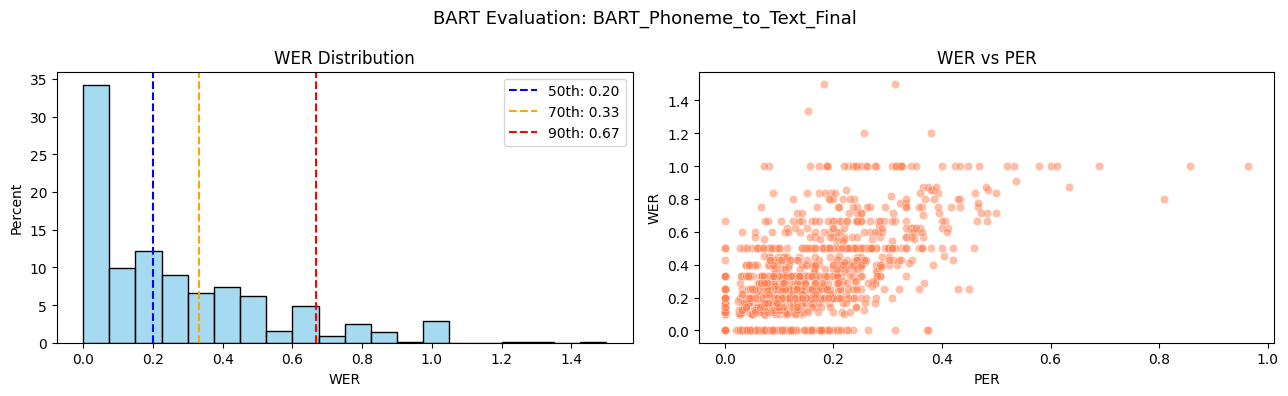

In [17]:
# ================================================================
# Run evaluation
# ================================================================
if EVAL_TYPE == 'bart':
    avg_wer, avg_per, bleu, rougeL = evaluate_bart_model(
        EVAL_MODEL_PATH, val_dataset_hf,
        beam_size=EVAL_BEAM_SIZE, batch_size=EVAL_BATCH_SIZE)
else:
    # Load Qwen model for evaluation
    bnb_config_eval = BitsAndBytesConfig(
        load_in_4bit=True, bnb_4bit_use_double_quant=True,
        bnb_4bit_quant_type='nf4', bnb_4bit_compute_dtype=torch.bfloat16)
    _base = AutoModelForCausalLM.from_pretrained(
        'Qwen/Qwen2.5-7B-Instruct', quantization_config=bnb_config_eval, device_map='auto')
    eval_qwen  = PeftModel.from_pretrained(_base, EVAL_MODEL_PATH)
    eval_qwen.eval()
    eval_tokenizer = AutoTokenizer.from_pretrained('Qwen/Qwen2.5-7B-Instruct')
    eval_tokenizer.pad_token = eval_tokenizer.eos_token
    avg_wer, avg_per, bleu, rougeL = evaluate_qwen_model(
        eval_qwen, eval_tokenizer, val_dataset_hf,
        beam_size=EVAL_BEAM_SIZE, batch_size=EVAL_BATCH_SIZE)

These cells are the same as the previous cells,just to show the result of qwen

For downloding the qwen weight, it is better to use your own token, which will be much more faster than unauthenticated

In [10]:
# ================================================================
# ⚙️  Evaluation config — edit before running
# ================================================================

EVAL_TYPE       = 'qwen'   # 'bart' or 'qwen'
EVAL_MODEL_PATH = QWEN_LORA_SAVE   # path to the checkpoint to evaluate
EVAL_BEAM_SIZE  = 4
EVAL_BATCH_SIZE = 60

In [11]:
# ================================================================
# Run evaluation
# ================================================================
if EVAL_TYPE == 'bart':
    avg_wer, avg_per, bleu, rougeL = evaluate_bart_model(
        EVAL_MODEL_PATH, val_dataset_hf,
        beam_size=EVAL_BEAM_SIZE, batch_size=EVAL_BATCH_SIZE)
else:
    login("your token")

    # Load Qwen model for evaluation
    bnb_config_eval = BitsAndBytesConfig(
        load_in_4bit=True, bnb_4bit_use_double_quant=True,
        bnb_4bit_quant_type='nf4', bnb_4bit_compute_dtype=torch.bfloat16)
    _base = AutoModelForCausalLM.from_pretrained(
        'Qwen/Qwen2.5-7B-Instruct', quantization_config=bnb_config_eval, device_map='auto')
    eval_qwen  = PeftModel.from_pretrained(_base, EVAL_MODEL_PATH)
    eval_qwen.eval()
    eval_tokenizer = AutoTokenizer.from_pretrained('Qwen/Qwen2.5-7B-Instruct')
    eval_tokenizer.pad_token = eval_tokenizer.eos_token


config.json:   0%|          | 0.00/663 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/243 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

NameError: name 'evaluate_qwen_model' is not defined


Evaluating Qwen 2.5


Generating (Qwen):   0%|          | 0/23 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.



--- 15 RANDOM EXAMPLES ---

Example 1:
  Input     : T UW | S EH P ER IH D | DH AH | N UW Z | F R AH M | DH AH | 
  Reference : To separate the news from the comment.
  Prediction: To separate the news from the comment.
  WER: 0.0000 | PER: 0.1562

Example 2:
  Input     : IH Z | DH AE T | P AH L UW SH AH N |
  Reference : Is that pollution?
  Prediction: Is that pollution?
  WER: 0.0000 | PER: 0.0000

Example 3:
  Input     : N EH V ER | M IH K S | AH | M OW M AH T |
  Reference : Never miss a moment!
  Prediction: Never mix a moment.
  WER: 0.2500 | PER: 0.1111

Example 4:
  Input     : L EH T S | M EY K | AH | P R OW G R AE M | F AO R | K IH D Z
  Reference : Let's make a program for kids.
  Prediction: Let's make a program for kids.
  WER: 0.0000 | PER: 0.0000

Example 5:
  Input     : AY | D IH D AH N T | N OW | DH EH R | W AA Z | S AH CH | AH 
  Reference : I didn't know there was such a thing.
  Prediction: I didn't know there was such a thing.
  WER: 0.0000 | PER: 0.0000

Exam

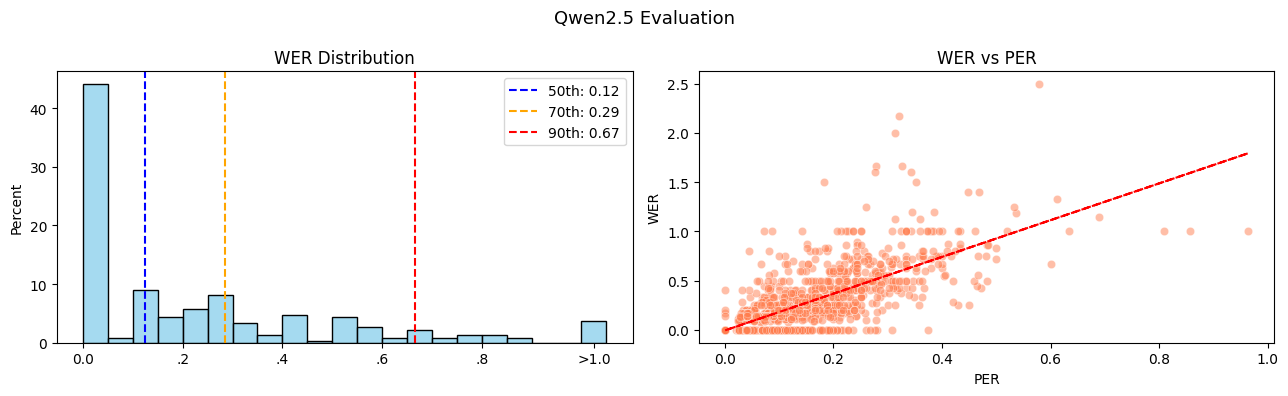

In [14]:
_SYSTEM_PROMPT = "You are an expert speech decoding system. Translate the noisy ARPAbet phonemes into English text. CRITICAL CONSTRAINTS: You must ONLY output valid English dictionary words. Output ONLY the final text."
avg_wer, avg_per, bleu, rougeL = evaluate_qwen_model(
        eval_qwen, eval_tokenizer, val_dataset_hf,
        beam_size=EVAL_BEAM_SIZE, batch_size=EVAL_BATCH_SIZE)

# LM Uncertainty Analysis

Computes per-sample LM uncertainty (negative beam-score for BART; negative mean token log-prob for Qwen), then analyses its correlation with WER, stratifies predictions by confidence level, and computes ECE.

Set `UNCERTAINTY_LM_TYPE` to `'bart'` or `'qwen'` and point `UNCERTAINTY_LM_PATH` at the checkpoint.

In [15]:
# ================================================================
# ⚙️  Uncertainty config — edit before running
# ================================================================

UNCERTAINTY_LM_TYPE = 'bart'      # 'bart' or 'qwen'
UNCERTAINTY_LM_PATH = BART_SAVE

In [16]:
# ================================================================
# Load LM for uncertainty analysis
# ================================================================
gc.collect(); torch.cuda.empty_cache()

if UNCERTAINTY_LM_TYPE == 'bart':
    unc_tokenizer = AutoTokenizer.from_pretrained(UNCERTAINTY_LM_PATH)
    unc_lm_model  = AutoModelForSeq2SeqLM.from_pretrained(UNCERTAINTY_LM_PATH).to(device)
    unc_lm_model.eval()
    print(f'BART loaded from {UNCERTAINTY_LM_PATH}')
else:
    _bnb = BitsAndBytesConfig(load_in_4bit=True,bnb_4bit_use_double_quant=True,
                               bnb_4bit_quant_type='nf4',bnb_4bit_compute_dtype=torch.bfloat16)
    _base2 = AutoModelForCausalLM.from_pretrained('Qwen/Qwen2.5-7B-Instruct',
                                                   quantization_config=_bnb, device_map='auto')
    unc_lm_model  = PeftModel.from_pretrained(_base2, UNCERTAINTY_LM_PATH)
    unc_tokenizer = AutoTokenizer.from_pretrained('Qwen/Qwen2.5-7B-Instruct')
    unc_tokenizer.pad_token = unc_tokenizer.eos_token
    unc_lm_model.eval()
    print(f'Qwen loaded from {UNCERTAINTY_LM_PATH}')

Loading weights:   0%|          | 0/260 [00:00<?, ?it/s]

BART loaded from /content/drive/MyDrive/SpeechModels/BART_Phoneme_to_Text_Final


In [17]:
# ================================================================
# Unified uncertainty pipeline
# ================================================================

def run_uncertainty_pipeline(acoustic_model, lm_model, lm_tokenizer, data_loader,
                              device, args, lm_type='bart'):
    acoustic_model.eval(); lm_model.eval()
    if lm_type == 'qwen': lm_tokenizer.padding_side = 'left'
    k_w, s_w = args.pool_kernel, args.pool_stride
    all_wers, all_pers, all_lm_uncs, all_am_uncs = [], [], [], []
    samples = []

    print(f'Running {lm_type.upper()} uncertainty pipeline...')
    with torch.no_grad():
        for neural_batch, phoneme_batch, seq_lens, input_time_steps, text_labels in tqdm(data_loader):
            neural_batch = neural_batch.to(device)
            il = compute_token_lengths(input_time_steps, k_w, s_w).to(device)
            T_p = neural_batch.size(-1)
            P = compute_token_lengths(torch.tensor([T_p]), k_w, s_w).item()
            seq_range = torch.arange(P, device=device).expand(neural_batch.size(0), P)
            attn_mask = (seq_range < il.unsqueeze(1)).unsqueeze(1).unsqueeze(2)

            log_probs = acoustic_model(neural_batch, mask=attn_mask).log_softmax(dim=-1)
            am_unc    = compute_am_sequence_score(log_probs, il)
            pred_ids  = ctc_greedy_decode(log_probs, blank_id=0)

            phoneme_strings, batch_pers = [], []
            for i, pid in enumerate(pred_ids):
                tl  = seq_lens[i].item()
                ts  = [x for x in phoneme_batch[i][:tl].tolist() if x != 0]
                batch_pers.append(calculate_per(ts, pid)); all_pers.append(batch_pers[-1])
                phoneme_strings.append(' '.join(LOGIT_TO_PHONEME[p] for p in pid if p < NUM_PHONEMES))

            # LM inference & uncertainty
            if lm_type == 'bart':
                enc = lm_tokenizer(phoneme_strings, return_tensors='pt', padding=True,
                                   max_length=256, truncation=True).to(device)
                out = lm_model.generate(
                    input_ids=enc.input_ids, attention_mask=enc.attention_mask,
                    max_length=256, num_beams=4, length_penalty=0.6,
                    output_scores=True, return_dict_in_generate=True)
                lm_unc    = (-out.sequences_scores.cpu()).tolist()
                pred_texts = lm_tokenizer.batch_decode(out.sequences, skip_special_tokens=True)

            else:  # qwen
                prompts = [f'<|im_start|>system\n{_SYSTEM_PROMPT}<|im_end|>\n'
                           f'<|im_start|>user\nPhonemes: {ph}<|im_end|>\n<|im_start|>assistant\n'
                           for ph in phoneme_strings]
                enc = lm_tokenizer(prompts, return_tensors='pt', padding=True,
                                   truncation=True, max_length=512).to(lm_model.device)
                out = lm_model.generate(
                    **enc, max_new_tokens=64, num_beams=4, do_sample=False,
                    output_scores=True, return_dict_in_generate=True,
                    early_stopping=True, length_penalty=0.8, repetition_penalty=1.1)
                ts_scores = lm_model.compute_transition_scores(
                    out.sequences, out.scores, out.beam_indices, normalize_logits=True)
                lm_unc = []
                for k in range(len(ts_scores)):
                    valid = ts_scores[k][ts_scores[k] != 0]
                    lm_unc.append(-valid.mean().item() if len(valid) > 0 else 10.0)
                pl = enc.input_ids.shape[1]
                pred_texts = lm_tokenizer.batch_decode(out.sequences[:, pl:], skip_special_tokens=True)

            for i, pred_text in enumerate(pred_texts):
                true_text = text_labels[i]
                if isinstance(true_text, bytes): true_text = true_text.decode('utf-8')
                wer = calculate_wer(true_text, pred_text)
                all_wers.append(wer); all_lm_uncs.append(lm_unc[i]); all_am_uncs.append(am_unc[i].item())
                if len(samples) < 15:
                    samples.append({'am_unc':am_unc[i].item(),'lm_unc':lm_unc[i],
                                    'per':batch_pers[i],'pred':pred_text,'true':true_text,'wer':wer})

    # Print sample table
    print(f"\n{'AM_UNC':<10} | {'LM_UNC':<10} | {'PER':<8} | {'WER':<8} | {'Predicted':<35} | True")
    print('-'*105)
    for s in samples:
        print(f"{s['am_unc']:.4f}    | {s['lm_unc']:.4f}    | {s['per']:.2%}  | {s['wer']:.2%}  | "
              f"{s['pred'][:33]:<35} | {s['true']}")

    # Correlations
    print(f'\n--- Uncertainty Correlations ---')
    print(f'LM uncertainty vs WER: {np.corrcoef(all_lm_uncs, all_wers)[0,1]:.3f}')
    print(f'LM uncertainty vs PER: {np.corrcoef(all_lm_uncs, all_pers)[0,1]:.3f}')
    print(f'AM uncertainty vs WER: {np.corrcoef(all_am_uncs, all_wers)[0,1]:.3f}')
    print(f'AM uncertainty vs PER: {np.corrcoef(all_am_uncs, all_pers)[0,1]:.3f}')
    print(f'Mean WER: {np.mean(all_wers):.2%}  |  Median WER: {np.median(all_wers):.2%}')
    print(f'Mean PER: {np.mean(all_pers):.2%}')

    # LM confidence stratification
    print(f'\n--- LM Confidence Stratification ---')
    if lm_type == 'bart':
        boundaries = [(0,0.05,'HIGH    '),(0.05,0.15,'MEDIUM  '),(0.15,0.25,'LOW     '),(0.25,9999,'VERY_LOW')]
    else:  # Qwen: use quartiles
        q25,q50,q75 = np.percentile(all_lm_uncs,[25,50,75])
        boundaries = [(0,q25,'HIGH    '),(q25,q50,'MEDIUM  '),(q50,q75,'LOW     '),(q75,9999,'VERY_LOW')]
        print(f'(Quartile boundaries: {q25:.3f} / {q50:.3f} / {q75:.3f})')
    for lo, hi, label in boundaries:
        grp = [w for w,u in zip(all_wers,all_lm_uncs) if lo<=u<hi]
        if grp:
            print(f"{label}: {len(grp):4d} samples ({len(grp)/len(all_wers):.1%}),  "
                  f"mean WER={np.mean(grp):.2%},  median WER={np.median(grp):.2%}")

    # 4-panel plot
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f'{lm_type.upper()} Pipeline Uncertainty Analysis', fontsize=14)
    n_bins = 10
    def _calibration(uncs, errors, ax, xlabel, title, color):
        si = np.argsort(uncs)
        se = [errors[i] for i in si]; su = [uncs[i] for i in si]
        bs = max(len(se)//n_bins, 1)
        ax.plot([np.mean(su[i*bs:(i+1)*bs]) for i in range(n_bins)],
                [np.mean(se[i*bs:(i+1)*bs]) for i in range(n_bins)],'o-',color=color)
        ax.set_xlabel(xlabel); ax.set_ylabel('Average Error Rate'); ax.set_title(title); ax.grid(True,alpha=0.3)
    _calibration(all_lm_uncs, all_wers, axes[0,0], 'LM Uncertainty', 'LM Calibration Curve (WER)', 'blue')
    corr_lm=np.corrcoef(all_lm_uncs,all_wers)[0,1]
    axes[0,1].scatter(all_lm_uncs,all_wers,alpha=0.3,s=15,color='purple')
    axes[0,1].set_title(f'LM Uncertainty vs WER (r={corr_lm:.3f})'); axes[0,1].set_xlabel('LM Uncertainty'); axes[0,1].set_ylabel('WER'); axes[0,1].grid(True,alpha=0.3)
    _calibration(all_am_uncs, all_pers, axes[1,0], 'AM Uncertainty', 'AM Calibration Curve (PER)', 'red')
    corr_am=np.corrcoef(all_am_uncs,all_pers)[0,1]
    axes[1,1].scatter(all_am_uncs,all_pers,alpha=0.3,s=15,color='green')
    axes[1,1].set_title(f'AM Uncertainty vs PER (r={corr_am:.3f})'); axes[1,1].set_xlabel('AM Uncertainty'); axes[1,1].set_ylabel('PER'); axes[1,1].grid(True,alpha=0.3)
    plt.tight_layout(); plt.show()

    return all_wers, all_pers, all_am_uncs, all_lm_uncs


print('Uncertainty pipeline defined.')

Uncertainty pipeline defined.


Running BART uncertainty pipeline...


  0%|          | 0/50 [00:00<?, ?it/s]


AM_UNC     | LM_UNC     | PER      | WER      | Predicted                           | True
---------------------------------------------------------------------------------------------------------
0.0640    | 0.3597    | 13.51%  | 12.50%  | We definitely need a bigger in th   | We definitely need a change in the system.
0.0363    | 0.4410    | 11.11%  | 60.00%  | Teams news on by company.           | terms news earning by commitment
0.0289    | 0.3034    | 4.17%  | 0.00%  | This may seem important now.        | This may seem important now.
0.0155    | 0.0573    | 14.29%  | 33.33%  | The kids liked to go.               | The kids like to go out.
0.0411    | 0.4051    | 16.13%  | 0.00%  | We will have to place a large ord   | We will have to place a large order.
0.0372    | 0.3312    | 3.57%  | 0.00%  | Not in terms of north and south.    | Not in terms of north and south.
0.0095    | 0.0003    | 0.00%  | 0.00%  | He could get hurt.                  | He could get hurt.
0.0216    | 0.01

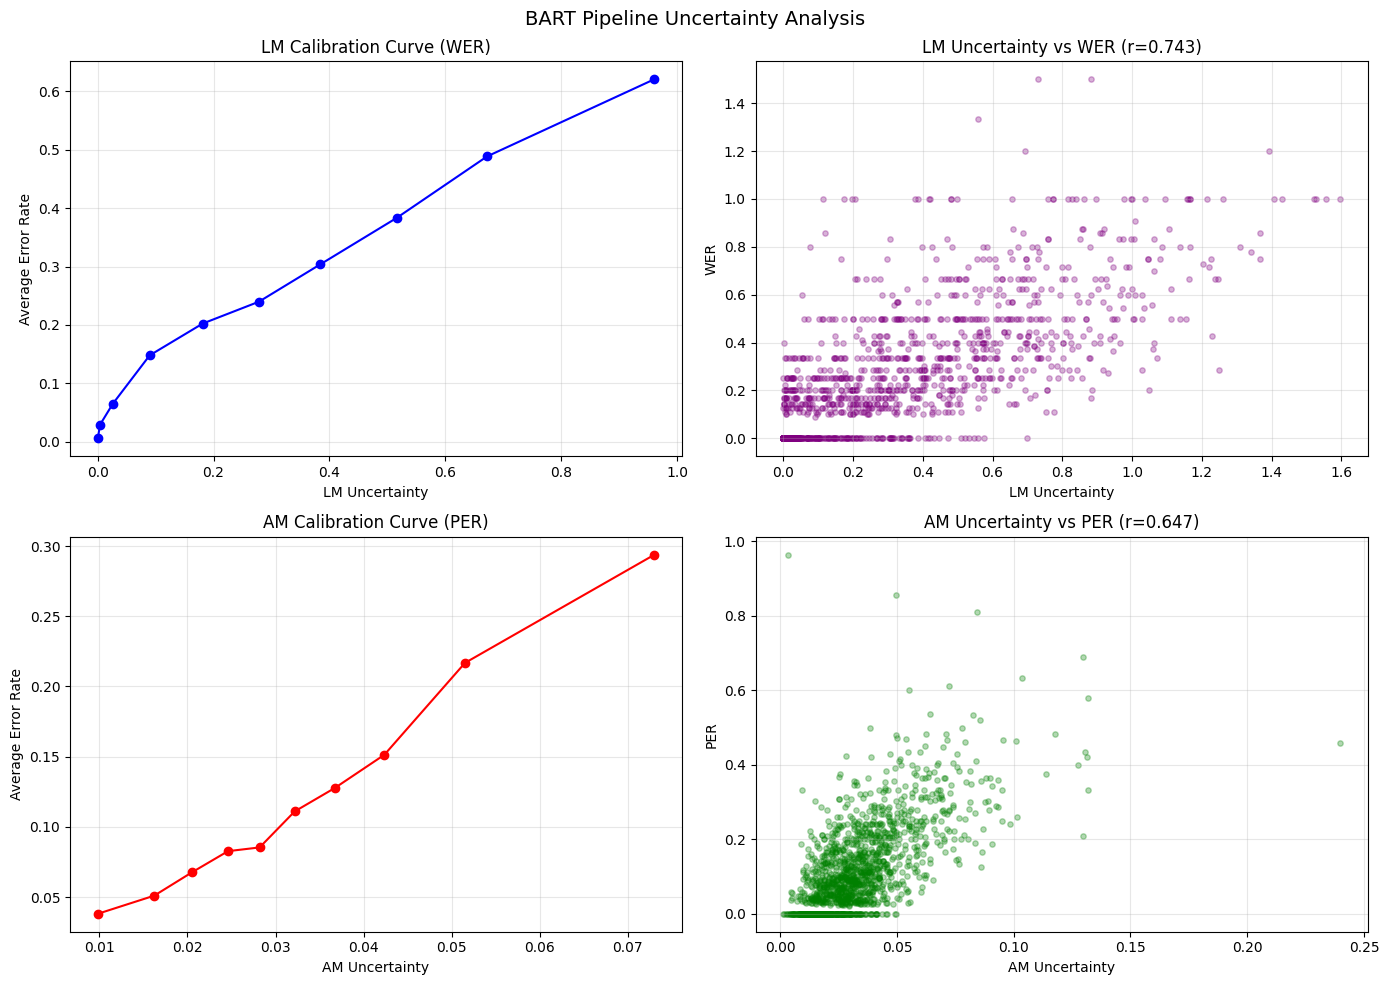

In [18]:
# Run uncertainty analysis
all_wers, all_pers, all_am_uncs, all_lm_uncs = run_uncertainty_pipeline(
    acoustic_model, unc_lm_model, unc_tokenizer,
    val_loader, device, args, lm_type=UNCERTAINTY_LM_TYPE)

In [19]:
# ================================================================
# ⚙️  Uncertainty config — edit before running
# ================================================================

UNCERTAINTY_LM_TYPE = 'qwen'      # 'bart' or 'qwen'
UNCERTAINTY_LM_PATH = QWEN_LORA_SAVE

In [20]:
# ================================================================
# Load LM for uncertainty analysis
# ================================================================
gc.collect(); torch.cuda.empty_cache()

if UNCERTAINTY_LM_TYPE == 'bart':
    unc_tokenizer = AutoTokenizer.from_pretrained(UNCERTAINTY_LM_PATH)
    unc_lm_model  = AutoModelForSeq2SeqLM.from_pretrained(UNCERTAINTY_LM_PATH).to(device)
    unc_lm_model.eval()
    print(f'BART loaded from {UNCERTAINTY_LM_PATH}')
else:
    login("your token")
    _bnb = BitsAndBytesConfig(load_in_4bit=True,bnb_4bit_use_double_quant=True,
                               bnb_4bit_quant_type='nf4',bnb_4bit_compute_dtype=torch.bfloat16)
    _base2 = AutoModelForCausalLM.from_pretrained('Qwen/Qwen2.5-7B-Instruct',
                                                   quantization_config=_bnb, device_map='auto')
    unc_lm_model  = PeftModel.from_pretrained(_base2, UNCERTAINTY_LM_PATH)
    unc_tokenizer = AutoTokenizer.from_pretrained('Qwen/Qwen2.5-7B-Instruct')
    unc_tokenizer.pad_token = unc_tokenizer.eos_token
    unc_lm_model.eval()
    print(f'Qwen loaded from {UNCERTAINTY_LM_PATH}')

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

Qwen loaded from /content/drive/MyDrive/SpeechModels/Qwen2.5_Phoneme_to_Text_LoRA_syntactic


Running QWEN uncertainty pipeline...


  0%|          | 0/50 [00:00<?, ?it/s]


AM_UNC     | LM_UNC     | PER      | WER      | Predicted                           | True
---------------------------------------------------------------------------------------------------------
0.0149    | 0.0003    | 0.00%  | 0.00%  | Go over there.                      | Go over there.
0.0077    | 0.0001    | 0.00%  | 0.00%  | Is that pollution?                  | Is that pollution?
0.0160    | 0.0012    | 0.00%  | 0.00%  | Are you recycling?                  | Are you recycling?
0.0084    | 0.0010    | 0.00%  | 0.00%  | They're grown now.                  | They're grown now.
0.0256    | 0.3105    | 26.09%  | 50.00%  | They really reject him.             | They recently released him.
0.0043    | 0.0001    | 0.00%  | 0.00%  | My three year old.                  | My three year old.
0.0712    | 0.2040    | 46.67%  | 75.00%  | Not do plagiarism.                  | Not too long ago.
0.0323    | 0.1009    | 11.11%  | 25.00%  | Easier way out maybe.               | Easiest way out may

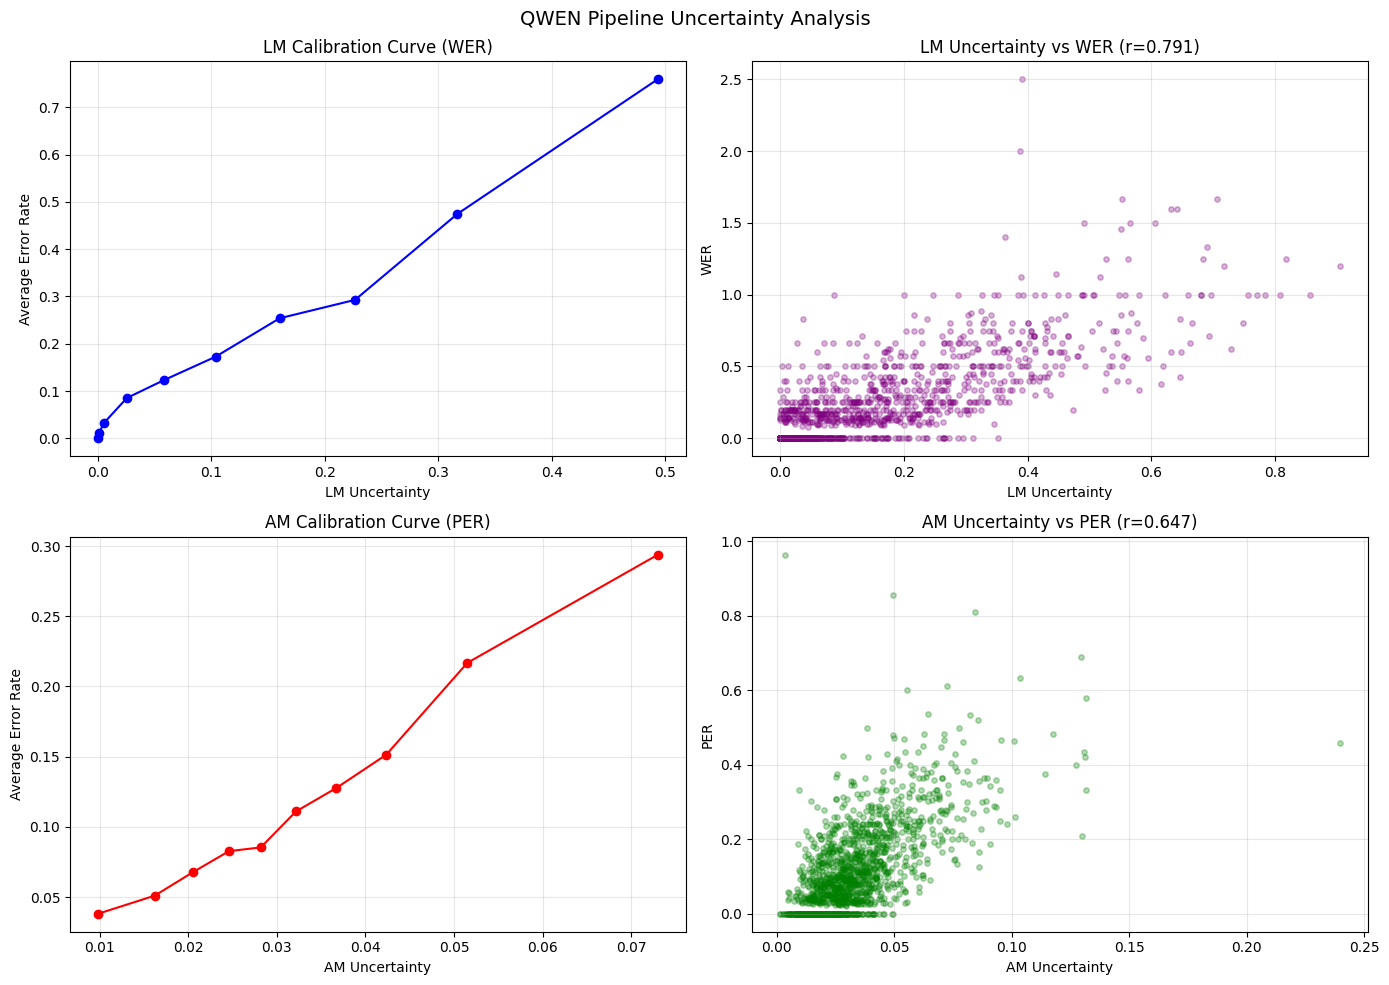

In [21]:
# Run uncertainty analysis
all_wers, all_pers, all_am_uncs, all_lm_uncs = run_uncertainty_pipeline(
    acoustic_model, unc_lm_model, unc_tokenizer,
    val_loader, device, args, lm_type=UNCERTAINTY_LM_TYPE)